# TensorFlow 선형회귀 실습: 보스턴 주택가격 데이터

이번 실습에서는 보스턴 주택가격 데이터를 활용하여 선형회귀를 적용해봅니다.




## Dataset 설명
- California Housing Dataset은 캘리포니아 주의 주택 가격과 관련된 다양한 특성들을 포함하고 있습니다.
- 이 데이터셋은 주택 가격 예측과 관련된 머신러닝 모델을 개발하는 데 자주 사용됩니다.
- 데이터셋은 8개의 특성과 1개의 타겟 변수로 구성되어 있습니다.

### 특성 설명:
- MedHouseValue (target): 주택 가격 (단위: 10만 달러)
- MedInc: 중간 소득 (단위: 10,000 달러)
- HouseAge: 주택 연령 (단위: 년)
- AveRooms: 평균 방 개수
- AveBedrms: 평균 침실 개수
- Population: 인구 수
- AveOccup: 평균 가구원 수
- Latitude: 위도
- Longitude: 경도

## 실습 목표
1. 데이터 불러오기 및 전처리
2. 데이터 시각화
3. TensorFlow를 활용한 선형회귀 모델 정의 및 학습
4. 결과 해석 및 시각화

In [31]:
# matplotlib 폰트 깨짐 현상 해결
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

## 문제 1. 데이터 불러오기

In [32]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# ----------------------
# 1. 데이터 불러오기
# ----------------------
california = fetch_california_housing()
print(california.data.shape)
X = california.data         # Attributes (8개 특성)
y = california.target       # Target (주택가격)

print("X shape:", X.shape, "y shape:", y.shape)

(20640, 8)
X shape: (20640, 8) y shape: (20640,)


## 문제 2. 데이터 시각화

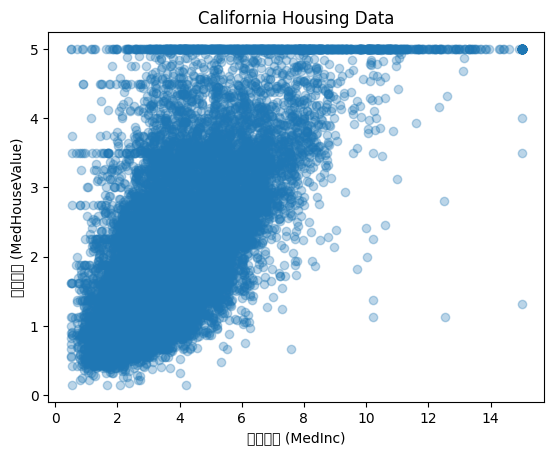

In [33]:
plt.scatter(X[:, 0], y, alpha=0.3)
plt.xlabel("중간소득 (MedInc)")
plt.ylabel("주택가격 (MedHouseValue)")
plt.title("California Housing Data")
plt.show()

## 문제 3. 모델 정의 및 학습

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

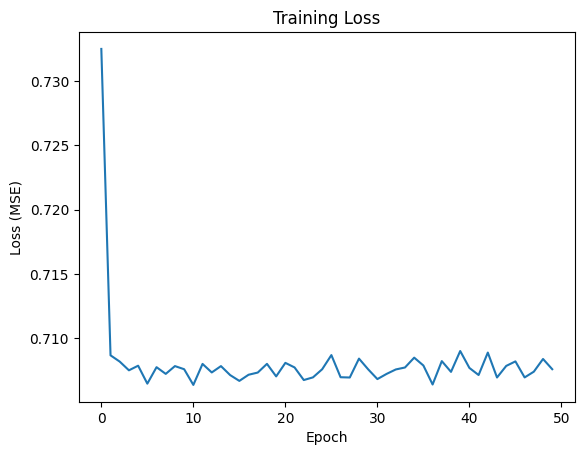

In [34]:
## 2. 모델 정의
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(1,)),
    tf.keras.layers.Dense(1)
])
model.summary()

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='mse')

history = model.fit(X[:, 0], y, epochs=50, verbose=0)

plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss")
plt.show()

## 문제 4. 학습 결과 확인

학습된 기울기 W: 0.413, 절편 b: 0.433
645/645 ━━━━━━━━━━━━━━━━━━━━ 1s 928us/step


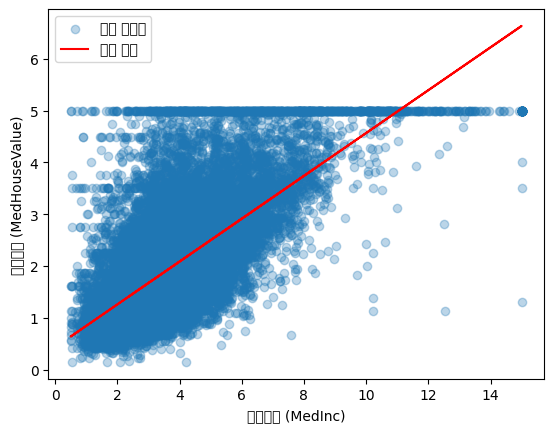

In [35]:
W, b = model.layers[0].get_weights()
print(f"학습된 기울기 W: {W[0][0]:.3f}, 절편 b: {b[0]:.3f}")

y_pred = model.predict(X[:, 0])

plt.scatter(X[:, 0], y, alpha=0.3, label="실제 데이터")
plt.plot(X[:, 0], y_pred, color='red', label="회귀 직선")
plt.xlabel("중간소득 (MedInc)")
plt.ylabel("주택가격 (MedHouseValue)")
plt.legend()
plt.show()

## 생각해보기
- 중간소득(MedInc) 외에 다른 특성들을 사용하여 모델을 개선할 수 있는가?
    - 다른 특성들을 사용해서 모델을 개선할 수 있음.
      - 다중 선형회귀의 장점
        - 현재 모델 : 단일특성만 사용 -> 1차원 선형 관계만 학습
        - 개선된 모델 : 8개 특성 모두 사용 -> 다차원 선형 관계 학습 가능
        - 예측 정확도 향상 : 더 많은 정보를 활용하여 주택가격을 더 정확히 예측

      - 추가할 수 있는 유용한 특성들
        - HouseAge : 주택 연령 - 오랜된 집일수록 가격이 낮아질 수 있음
        - AveRooms : 평균 방 개수 - 방이 많을수록 가격 상승
        - Population : 인구 수 - 인구 밀도가 가격에 영향
        - Latitude/Longitude : 위치 정보 - 지역별 가격 차이 반영

      - 기대되는 개선 효과
        - 결정계수 향상 : 0.4-0.5 -> 0.6-0.7로 개선 가능
        - 평균제곱오차 감소 : 예측 오차 크게 감소
        - 실제 적용 가능성 : 단일 특성보다 실용적인 모델

      - 주의사항
        - 특성 스케일링 : 특성들의 범위가 다르므로 정규화 필요
        - 다중공선성 : 특성들 간 상관관계 확인 필요
        - 과적합 방지 : 정규화 기법 적용 고려